# Business listings: data cleaning and exploratory analysis

This notebook turns the three raw collector outputs into the single clean dataset that is loaded into MySQL through the API, and documents every change made along the way.

| Stage | Input | Output |
|---|---|---|
| Collection | OpenStreetMap, Geoapify, RBI bank directory | `data/raw/*.csv` |
| **Cleaning (this notebook)** | `data/raw/*.csv` | `data/clean/listings_clean.csv` |
| Loading | clean CSV | MySQL `listing_master` via `POST /api/listings/bulk` |

The cleaning logic lives in [`scraper/clean_listings.py`](../scraper/clean_listings.py) so it can also run without the notebook; this notebook calls the same functions step by step and shows their effect. Source selection and terms-of-service checks are documented in [`docs/DATA_SOURCES.md`](../docs/DATA_SOURCES.md).

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("..").resolve() / "scraper"))
import clean_listings as cl

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 160)

# Chart style: validated categorical palette, fixed order per source; recessive axes
SOURCE_COLORS = {"OpenStreetMap": "#2a78d6", "Geoapify": "#eb6834", "RBI Bank Directory": "#1baf7a"}
SOURCES = list(SOURCE_COLORS)
INK, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": GRID,
    "axes.labelcolor": INK_MUTED, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": GRID,
    "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlecolor": INK, "axes.titlelocation": "left", "legend.frameon": False,
})

## 1. Load the raw data

In [2]:
raw = cl.load_raw()
print(f"{len(raw)} raw rows, {raw.shape[1]} columns")
raw.groupby("source").size().rename("rows").to_frame()

23:17:47  INFO    Loaded geoapify_places.csv (390), osm_overpass.csv (390), rbi_bank_branches.csv (150)


930 raw rows, 10 columns


,rows
source,
Geoapify,390
OpenStreetMap,390
RBI Bank Directory,150


### 1.1 Raw data quality profile

Completeness of the brief's fields per source, plus the two most visible formatting problems.

In [3]:
def profile(df):
    g = df.groupby("source")
    return pd.DataFrame({
        "rows": g.size(),
        "address_%": (g["address"].apply(lambda s: s.notna().mean()) * 100).round(1),
        "phone_%": (g["phone"].apply(lambda s: s.notna().mean()) * 100).round(1),
        "ALL_CAPS_names": g["business_name"].apply(lambda s: s.str.isupper().sum()),
        "phone_formats": g["phone"].apply(lambda s: s.dropna().map(lambda p: re.sub(r"\d", "9", p)).nunique()),
    })

raw_profile = profile(raw)
raw_profile

,rows,address_%,phone_%,ALL_CAPS_names,phone_formats
source,,,,,
Geoapify,390,100.0,49.0,10,56
OpenStreetMap,390,99.2,87.4,8,78
RBI Bank Directory,150,100.0,88.0,6,6


In [4]:
# What "107 phone formats" looks like in practice (9 = any digit)
shapes = raw["phone"].dropna().map(lambda p: re.sub(r"\d", "9", p))
print(f"{shapes.nunique()} distinct phone formats across {raw['phone'].notna().sum()} numbers. Most common:")
shapes.value_counts().head(10).rename("count").to_frame()

107 distinct phone formats across 664 numbers. Most common:


,count
phone,
+999999999999,190
99999999999,50
9999999999,49
+99 99999 99999,45
999 9999 9999,32
+99 9999999999,29
+99 99 9999 9999,27
999999 99999,14
99999999,14


## 2. Cleaning, step by step

Each step is a function in `clean_listings.py` that returns the cleaned data and a one-line note. Steps never invent data: values are standardised, and anything that cannot be trusted is set to empty or dropped.

### Step 1: Tidy whitespace
Collapse repeated spaces, remove spaces before commas, add one after.

In [5]:
df, note = cl.step_tidy_whitespace(raw)
print(note)
changed = raw["address"].fillna("") != df["address"].fillna("")
pd.DataFrame({"before": raw.loc[changed, "address"], "after": df.loc[changed, "address"]}).head(4)

99 rows had extra/missing spaces or stray commas fixed


,before,after
39,"room no:1,line:f,plot no:12, Mohmmad Road, Shivaji Nagar...","room no:1, line:f, plot no:12, Mohmmad Road, Shivaji Nag..."
390,"B-403,suba zircon apartments, near suba international ho...","B-403, suba zircon apartments, near suba international h..."
402,"S V Road , Vile Parle","S V Road, Vile Parle"
441,"250, MEHBOOB E SUBHANI MASJID, 250 BHALEKAR WADI, New Mi...","250, MEHBOOB E SUBHANI MASJID, 250 BHALEKAR WADI, New Mi..."


### Step 2: Fix ALL-CAPS text
The RBI directory is written in capitals. Upper-case parts are title-cased, but a name that *starts* with a single upper-case word keeps it, because that is usually a brand (OYO, VLCC), and vowel-less abbreviations (MW, GR) stay upper case.

In [6]:
before = df.copy()
df, note = cl.step_fix_capitals(df)
print(note)
changed = before["business_name"] != df["business_name"]
pd.DataFrame({"before": before.loc[changed, "business_name"], "after": df.loc[changed, "business_name"]}).sample(6, random_state=1)

162 names and 154 addresses converted from ALL CAPS


,before,after
811,"Canara Bank - F CANNUAGHT CIRCUS, NEW DELHI","Canara Bank - F Cannuaght Circus, New Delhi"
814,City Union Bank - NEW DELHI,City Union Bank - New Delhi
878,Punjab National Bank - CHENNAI-MOUNT ROAD,Punjab National Bank - Chennai-Mount Road
844,ICICI Bank - BANGALOREM G ROAD,ICICI Bank - Bangalorem G Road
927,RBL Bank - ICC TRADE CENTRE,RBL Bank - Icc Trade Centre
714,LIV IT,Liv It


In [7]:
# Brands and acronyms are deliberately left alone
pd.DataFrame({"input": ["OYO", "VLCC", "KCROASTERS - By Koinonia", "SATYA NARAYANA CAFE", "Axis Bank - BRAHMAND THANE"]}).assign(
    output=lambda d: d["input"].map(cl.fix_caps))

,input,output
0,OYO,OYO
1,VLCC,VLCC
2,KCROASTERS - By Koinonia,KCROASTERS - By Koinonia
3,SATYA NARAYANA CAFE,Satya Narayana Cafe
4,Axis Bank - BRAHMAND THANE,Axis Bank - Brahmand Thane


### Step 3: Remove the redundant ", India" suffix
Every listing is in India, so the suffix adds nothing.

In [8]:
df, note = cl.step_trim_address_country(df)
print(note)

392 addresses had the redundant ', India' suffix removed


### Step 4: Normalise phone numbers
Rules, in dialling order: keep the first number when several are listed; strip `00`, then the `91` country code, then the `0` trunk prefix; add the city's area code to 8-digit local landlines. The result must be exactly 10 digits, otherwise it is not a valid Indian number and is set to empty (never guessed).

Output formats: mobile `+91 98765 43210`, landline in a target city `+91 22 2401 4419`, other landline `+91 XXX XXX XXXX`.

In [9]:
before = df.copy()
df, note = cl.step_normalise_phones(df)
print(note)
examples = pd.DataFrame({"city": before["city"], "before": before["phone"], "after": df["phone"]}).dropna(subset=["before"])
examples.sample(8, random_state=3)

664 phones put in one +91 format (62 had several numbers, first kept); 22 invalid numbers set to empty


,city,before,after
503,Delhi,+91 011 24333178,+91 11 2433 3178
730,Pune,07304657338,+91 73046 57338
693,Hyderabad,040 27019223,+91 40 2701 9223
598,Chennai,+91 9840055922,+91 98400 55922
682,Hyderabad,040 23223782;040 23223792;040 66069000,+91 40 2322 3782
89,Delhi,28758071,+91 11 2875 8071
702,Hyderabad,+91 98851 28158,+91 98851 28158
505,Delhi,01141669775,+91 11 4166 9775


In [10]:
# Numbers that could not be validated: toll-free lines, too few/many digits, spreadsheet corruption (1.13E+42)
examples[examples["after"].isna()].head(10)

,city,before,after
2,Mumbai,93657482838,NaN
166,Bengaluru,+91 80 252171841,NaN
409,Mumbai,1860 266 0010,NaN
417,Mumbai,1234335,NaN
442,Mumbai,18008910001,NaN
444,Mumbai,54789754754238,NaN
471,Delhi,971529571,NaN
484,Delhi,1.13E+42,NaN
511,Delhi,+91 11 3218206,NaN
557,Bengaluru,953555104,NaN


### Steps 5-6: Required fields and valid cities
Every row must have a name, category, city and source, and the city must be one of the six targets.

In [11]:
df, note = cl.step_drop_missing_required(df); print(note)
df, note = cl.step_validate_values(df); print(note)

0 rows dropped for a missing name, category, city or source
0 rows dropped with a city outside the 6 target cities


### Step 7: Exact duplicates
Same normalised name, address, city and source, using the same normalisation as the API's `dedupe_key`.

In [12]:
keys = pd.Series([cl._key(*r) for r in df[["business_name", "address", "city", "source"]].itertuples(index=False)], index=df.index)
display(df[keys.duplicated(keep=False)][["business_name", "address", "city", "source", "source_id"]])
df, note = cl.step_drop_exact_duplicates(df)
print(note)

,business_name,address,city,source,source_id
52,Agile Fingers,"Manuel Gonsalves Road, H/W Ward, Mumbai - 400050, Mahara...",Mumbai,Geoapify,node/5273193980
53,Agile Fingers,"Manuel Gonsalves Road, H/W Ward, Mumbai - 400050, Mahara...",Mumbai,Geoapify,node/12716963146
633,Electrical Shop,West Jones Road,Chennai,OpenStreetMap,node/4308319496
634,Electrical Shop,West Jones Road,Chennai,OpenStreetMap,node/4308320095


2 exact duplicates removed (same name, address, city and source)


Both pairs are the same shop mapped twice in OpenStreetMap (two node ids, identical details), so one copy of each is removed.

### Step 8: Cross-source duplicates
The same business listed by two sources (same name and city, within 150 m). The more complete record is kept.

In [13]:
df, note = cl.step_drop_cross_source_duplicates(df)
print(note)

0 cross-source duplicates removed (same name and city, within 150 m)


None were found, which is expected: Geoapify builds on OpenStreetMap, so the Geoapify collector already skipped every place whose OpenStreetMap id had been collected (111 overlaps removed at collection time). Twelve names do appear in both files for the same city (e.g. *Cafe Coffee Day*), but they are different branches at different addresses, so they are correctly kept.

## 3. Cleaning summary

In [14]:
clean, report = cl.run_pipeline(raw)
pd.DataFrame(report).set_index("step")

,rows_before,rows_after,note
step,,,
Tidy whitespace,930,930,99 rows had extra/missing spaces or stray commas fixed
Fix ALL-CAPS text,930,930,162 names and 154 addresses converted from ALL CAPS
"Trim ', India'",930,930,"392 addresses had the redundant ', India' suffix removed"
Normalise phones,930,930,664 phones put in one +91 format (62 had several numbers...
Drop rows missing required fields,930,930,"0 rows dropped for a missing name, category, city or source"
Validate cities,930,930,0 rows dropped with a city outside the 6 target cities
Remove exact duplicates,930,928,"2 exact duplicates removed (same name, address, city and..."
Remove cross-source duplicates,928,928,"0 cross-source duplicates removed (same name and city, w..."


In [15]:
clean_profile = profile(clean).drop(columns="ALL_CAPS_names")
comparison = pd.concat({"raw": raw_profile[["rows", "address_%", "phone_%", "phone_formats"]], "clean": clean_profile}, axis=1)
comparison

raw                                 clean                                
                   rows address_% phone_% phone_formats  rows address_% phone_% phone_formats
source                                                                                       
Geoapify            390     100.0    49.0            56   389     100.0    48.6             2
OpenStreetMap       390      99.2    87.4            78   389      99.2    84.3             3
RBI Bank Directory  150     100.0    88.0             6   150     100.0    83.3             3

Phone completeness drops slightly (for example OpenStreetMap 87.4% to 84.3%) because invalid numbers were removed rather than kept; a missing phone is more honest than a wrong one. Formats fall from dozens per source to the three standard patterns.

## 4. Exploratory analysis of the clean dataset

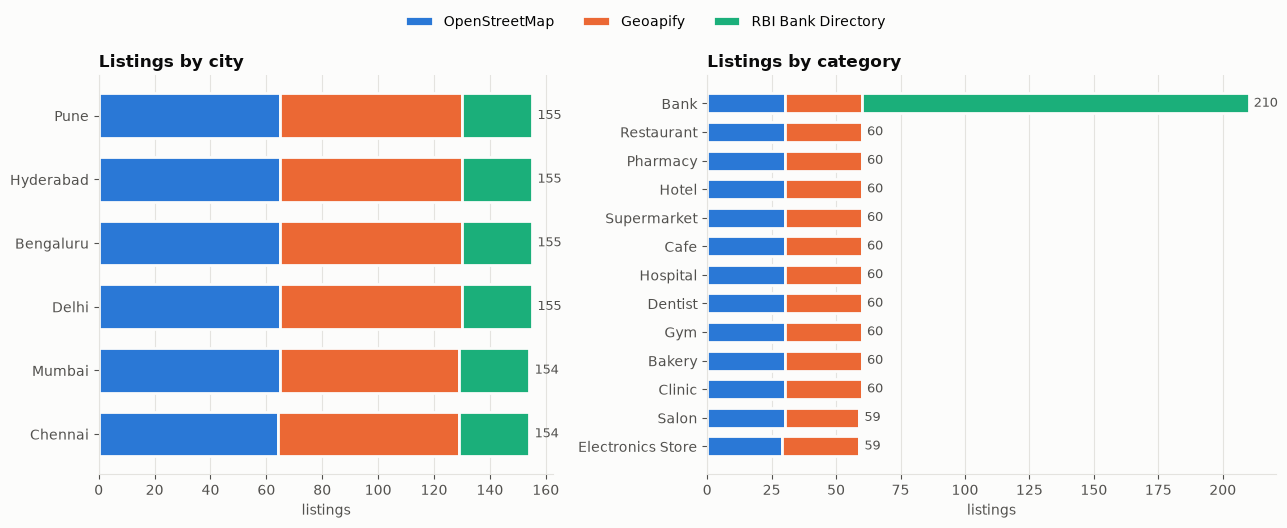

In [16]:
def stacked_barh(ax, table, title):
    table = table.reindex(columns=SOURCES, fill_value=0)
    table = table.loc[table.sum(axis=1).sort_values().index]
    left = pd.Series(0, index=table.index)
    for source in SOURCES:
        ax.barh(table.index, table[source], left=left, color=SOURCE_COLORS[source],
                edgecolor="#fcfcfb", linewidth=2, height=0.7, label=source)
        left += table[source]
    for y, total in enumerate(table.sum(axis=1)):
        ax.text(total + 2, y, str(total), va="center", color=INK_MUTED, fontsize=9)
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("listings")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1, 1.25]})
stacked_barh(ax1, pd.crosstab(clean["city"], clean["source"]), "Listings by city")
stacked_barh(ax2, pd.crosstab(clean["category"], clean["source"]), "Listings by category")
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

Cities are evenly balanced (154-155 each) by design: every collector caps listings per city and category. *Bank* is the largest category because the whole RBI source is bank branches, on top of banks from the two map sources.

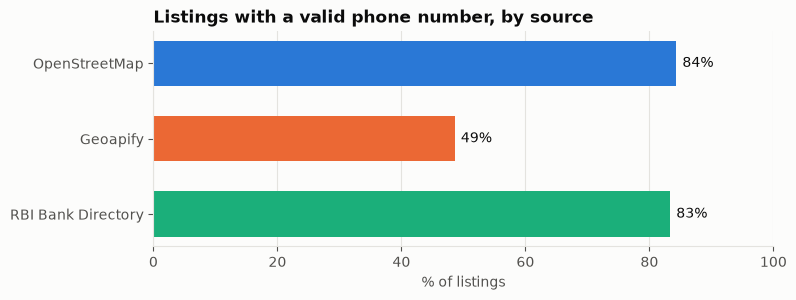

,address,phone
source,,
OpenStreetMap,99.2,84.3
Geoapify,100.0,48.6
RBI Bank Directory,100.0,83.3


In [17]:
coverage = (clean.groupby("source")[["address", "phone"]].agg(lambda s: s.notna().mean()) * 100).reindex(SOURCES)
fig, ax = plt.subplots(figsize=(8, 2.8))
y = range(len(coverage))
ax.barh(y, coverage["phone"], color=[SOURCE_COLORS[s] for s in coverage.index], height=0.6)
for i, v in enumerate(coverage["phone"]):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", color=INK, fontsize=10)
ax.set_yticks(list(y), coverage.index)
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.set_title("Listings with a valid phone number, by source")
ax.grid(axis="y", visible=False)
ax.set_xlabel("% of listings")
plt.show()
coverage.round(1)

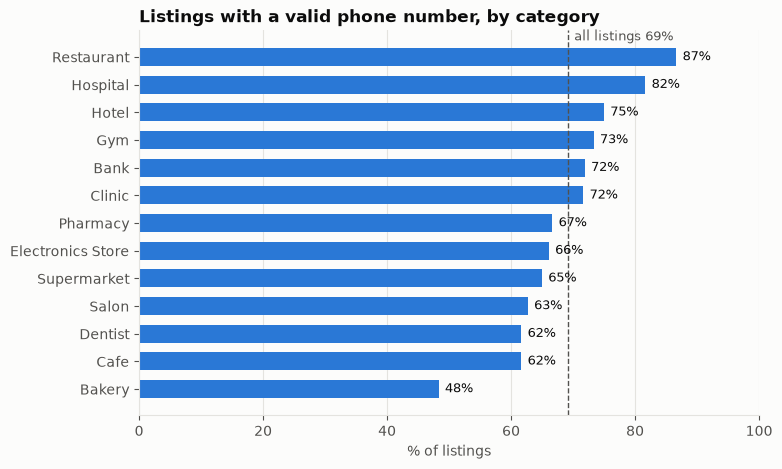

In [18]:
by_category = (clean.groupby("category")["phone"].apply(lambda s: s.notna().mean()) * 100).sort_values()
overall = clean["phone"].notna().mean() * 100
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(by_category.index, by_category.values, color="#2a78d6", height=0.65)
for i, v in enumerate(by_category.values):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", color=INK, fontsize=9)
ax.axvline(overall, color=INK_MUTED, linewidth=1, linestyle="--")
ax.text(overall + 1, len(by_category) - 0.4, f"all listings {overall:.0f}%", color=INK_MUTED, fontsize=9)
ax.set_xlim(0, 100)
ax.set_title("Listings with a valid phone number, by category")
ax.grid(axis="y", visible=False)
ax.set_xlabel("% of listings")
plt.show()

Contact coverage varies by business type: restaurants, hospitals and hotels usually publish a number (75-87%), while bakeries (48%) and cafes (62%) often do not, likely because they rely on walk-in trade rather than bookings. For a lead-generation use of this data, those categories would need a second source for phone numbers.

In [19]:
phones = clean["phone"].dropna()
phone_type = phones.map(lambda p: "Mobile" if re.match(r"^\+91 [6-9]\d{4} \d{5}$", p) else "Landline")
pd.DataFrame({"count": phone_type.value_counts(), "share_%": (phone_type.value_counts(normalize=True) * 100).round(1)})

,count,share_%
phone,,
Mobile,328,51.1
Landline,314,48.9


## 5. Key findings

- **928 clean listings** from 3 sources (OpenStreetMap 389, Geoapify 389, RBI bank directory 150), covering 6 cities and 13 categories: well above the 500 required.
- **Address completeness is 99.7%**; **69% of listings have a validated phone number**. Geoapify contributes the fewest phones (about 49%), the two others about 84%. By category, bakeries and cafes are least likely to list a phone.
- **Phone formats were the biggest quality problem:** 107 distinct raw formats were normalised to 3 standard patterns; 22 numbers that could not be valid (toll-free lines, wrong digit counts, a spreadsheet-corrupted value) were removed instead of guessed.
- **Duplicates:** 2 within-source duplicates removed; 0 cross-source duplicates, because overlap with OpenStreetMap was prevented at collection time.
- **Balance:** cities are evenly represented by design, so city comparisons on the dashboard reflect the sampling strategy, not market size. *Bank* is over-represented because one source is a bank directory.

## 6. Save the clean dataset

In [20]:
cl.save(clean)
saved = pd.read_csv(cl.CLEAN_PATH, encoding="utf-8-sig")
print(f"Saved {len(saved)} rows x {saved.shape[1]} columns -> {cl.CLEAN_PATH.relative_to(cl.ROOT_DIR)}")
saved.head()

Saved 928 rows x 7 columns -> data\clean\listings_clean.csv


,business_name,category,city,address,phone,source,source_id
0,Cake of the Day,Bakery,Bengaluru,"Outer Ring Road, Padmanabhanagara, Bengaluru - 560085, K...",NaN,Geoapify,node/5626258374
1,Choice Bakery,Bakery,Bengaluru,"12th Main, Contour Road, Kadirenahalli, Bengaluru - 5600...",NaN,Geoapify,node/2124814946
2,Iyengar's Bakery,Bakery,Bengaluru,"33, Outer Ring Road, Shakambarinagara, Bengaluru - 56007...",NaN,Geoapify,node/11303698304
3,Just Bake,Bakery,Bengaluru,"38th Cross Road, Pattabhirama Nagara, Bengaluru - 560041...",NaN,Geoapify,node/9904130020
4,Krishna Bakery,Bakery,Bengaluru,"26th Main Road, Tilak Nagara, Bengaluru - 560041, Karnataka",NaN,Geoapify,node/5234777582
